# Analyse exploratoire des données `crops/`

Ce notebook explore la structure du dossier `crops/` et les fichiers d'annotation disponibles dans `occlusion_datasets/`.

Objectifs :
- comprendre la structure des chemins d'images,
- mesurer les distributions des variables cibles,
- explorer la qualité des images,
- visualiser des exemples représentatifs et extrêmes.

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 120)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'occlusion_datasets'
CROPS_DIR = ROOT / 'crops' / 'Crop_224_5fp_100K'
TRAIN_CSV = DATA_DIR / 'train.csv'
TEST_CSV = DATA_DIR / 'test_students.csv'

TRAIN_CSV.exists(), TEST_CSV.exists(), CROPS_DIR.exists()

(True, True, True)

In [2]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print('train shape:', train_df.shape)
print('test shape:', test_df.shape)
print('\ntrain columns:', train_df.columns.tolist())
print('test columns:', test_df.columns.tolist())

train_df.head()

train shape: (100000, 3)
test shape: (29980, 1)

train columns: ['filename', 'FaceOcclusion', 'gender']
test columns: ['filename']


,filename,FaceOcclusion,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_align.webp,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align.webp,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_align.webp,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align.webp,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align.webp,0.252091,1.0


## 1. Structure des annotations

On commence par vérifier les colonnes, les valeurs manquantes et la forme générale des fichiers d'annotation.

In [3]:
annotation_summary = pd.DataFrame({
    'dtype': train_df.dtypes.astype(str),
    'missing_count': train_df.isna().sum(),
    'missing_ratio': train_df.isna().mean().round(4),
    'n_unique': train_df.nunique(dropna=False),
})

print('Duplicated rows:', train_df.duplicated().sum())
annotation_summary

Duplicated rows: 0


,dtype,missing_count,missing_ratio,n_unique
filename,str,0,0.0,100000
FaceOcclusion,float64,0,0.0,74258
gender,float64,0,0.0,2


## 2. Répartition des labels

Les variables `FaceOcclusion` et `gender` sont les cibles principales à comprendre avant l'entraînement.

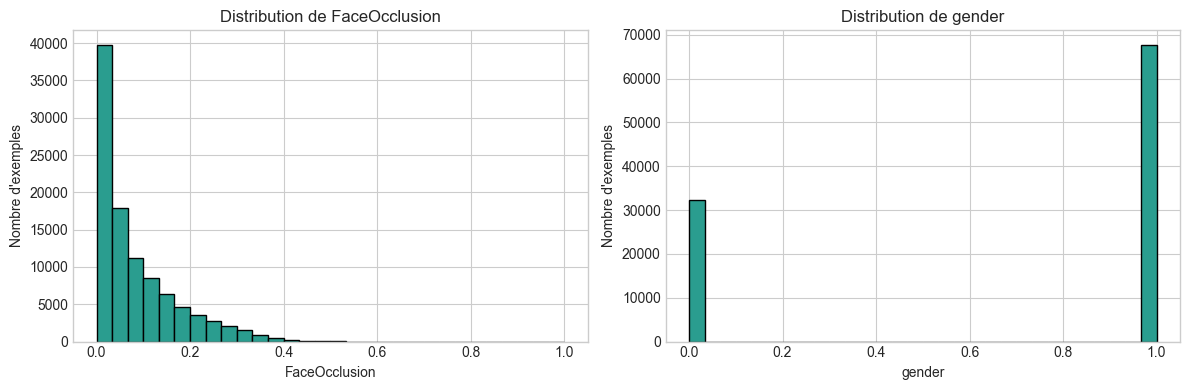

In [4]:
label_cols = [col for col in ['FaceOcclusion', 'gender'] if col in train_df.columns]

fig, axes = plt.subplots(1, len(label_cols), figsize=(12, 4))
if len(label_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, label_cols):
    train_df[col].dropna().plot(kind='hist', bins=30, ax=ax, color='#2a9d8f', edgecolor='black')
    ax.set_title(f'Distribution de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Nombre d\'exemples')

plt.tight_layout()
plt.show()

if set(label_cols) == {'FaceOcclusion', 'gender'}:
    train_df[['FaceOcclusion', 'gender']].corr(numeric_only=True)

## 3. Structure des chemins et couverture du dataset

On regarde où se trouvent les images, combien de sous-dossiers existent et si certaines branches contiennent beaucoup plus d'exemples que d'autres.

Top-level directories in train:
top_level_dir
database3    96023
database1     3747
database2      230
Name: count, dtype: int64


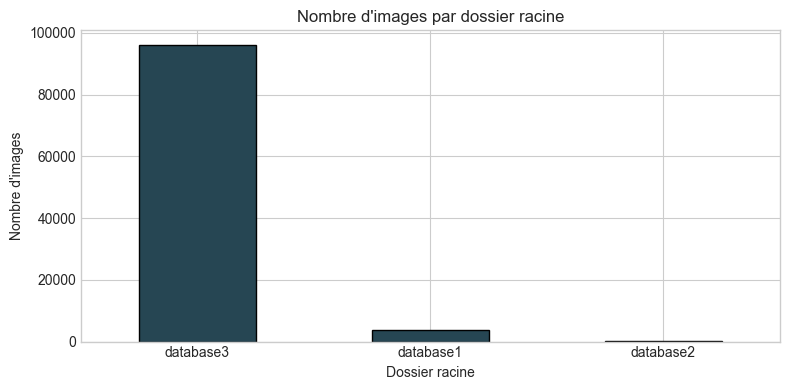

database3/database3/m.01w1069/116-FaceId-0_align.webp -> True
database3/database3/m.01rt1rf/9-FaceId-0_align.webp -> True
database3/database3/m.0266b03/98-FaceId-0_align.webp -> True
database3/database3/m.025xfy6/96-FaceId-0_align.webp -> True
database3/database3/m.026xn4s/111-FaceId-0_align.webp -> True
database3/database3/m.0286j_r/6-FaceId-0_align.webp -> True
database3/database3/m.01pn62t/30-FaceId-0_align.webp -> True
database3/database3/m.0272t9/9-FaceId-0_align.webp -> True


In [5]:
def path_parts(series):
    return series.astype(str).str.replace('\\', '/', regex=False).str.split('/')

train_paths = path_parts(train_df['filename'])
train_df['top_level_dir'] = train_paths.str[0]
train_df['nested_dir'] = train_paths.str[1].fillna('')

print('Top-level directories in train:')
print(train_df['top_level_dir'].value_counts(dropna=False))

fig, ax = plt.subplots(figsize=(8, 4))
train_df['top_level_dir'].value_counts().plot(kind='bar', ax=ax, color='#264653', edgecolor='black')
ax.set_title('Nombre d\'images par dossier racine')
ax.set_xlabel('Dossier racine')
ax.set_ylabel('Nombre d\'images')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

sample_paths = train_df['filename'].sample(min(8, len(train_df)), random_state=42).tolist()
for p in sample_paths:
    print(p, '->', (CROPS_DIR / p).exists())

## 4. Taille, format et qualité visuelle des images

On échantillonne les fichiers pour éviter un passage trop coûteux sur l'ensemble du dataset.

Corrupted / unreadable images: 0
       width  height  aspect_ratio
count  500.0   500.0         500.0
mean   224.0   224.0           1.0
std      0.0     0.0           0.0
min    224.0   224.0           1.0
25%    224.0   224.0           1.0
50%    224.0   224.0           1.0
75%    224.0   224.0           1.0
max    224.0   224.0           1.0

Image modes:
mode
RGB    500
Name: count, dtype: int64


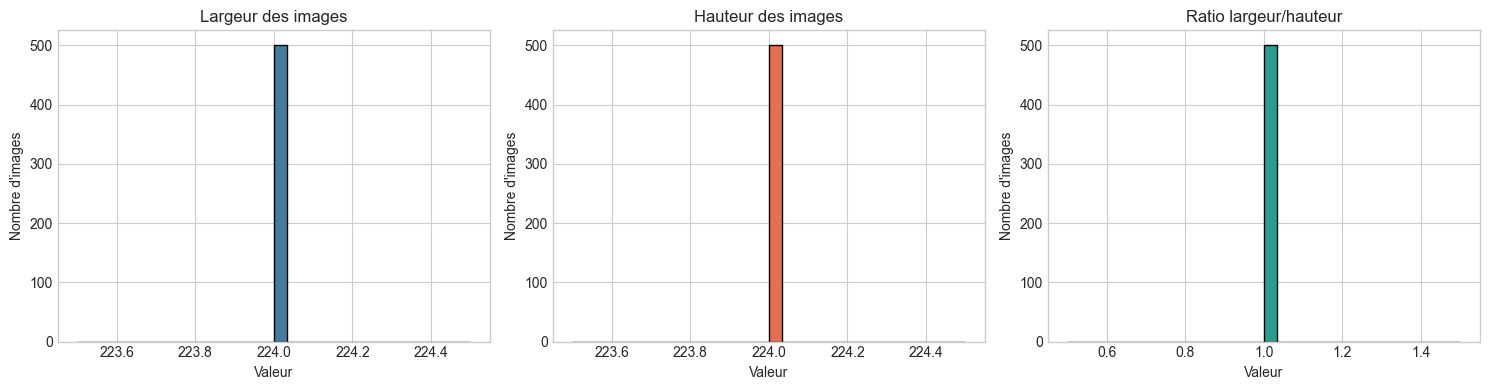

In [6]:
def inspect_image(path):
    try:
        with Image.open(path) as img:
            width, height = img.size
            return {
                'path': str(path),
                'width': width,
                'height': height,
                'aspect_ratio': round(width / height, 4) if height else np.nan,
                'mode': img.mode,
                'format': img.format,
            }
    except Exception as exc:
        return {
            'path': str(path),
            'width': np.nan,
            'height': np.nan,
            'aspect_ratio': np.nan,
            'mode': 'ERROR',
            'format': type(exc).__name__,
        }

sample_n = min(500, len(train_df))
image_sample = train_df['filename'].sample(sample_n, random_state=0) if sample_n else pd.Series(dtype=str)
image_info = pd.DataFrame([inspect_image(CROPS_DIR / p) for p in image_sample])

print('Corrupted / unreadable images:', (image_info['mode'] == 'ERROR').sum())
print(image_info[['width', 'height', 'aspect_ratio']].describe())
print('\nImage modes:')
print(image_info['mode'].value_counts(dropna=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
image_info['width'].dropna().plot(kind='hist', bins=30, ax=axes[0], color='#457b9d', edgecolor='black')
axes[0].set_title('Largeur des images')
image_info['height'].dropna().plot(kind='hist', bins=30, ax=axes[1], color='#e76f51', edgecolor='black')
axes[1].set_title('Hauteur des images')
image_info['aspect_ratio'].dropna().plot(kind='hist', bins=30, ax=axes[2], color='#2a9d8f', edgecolor='black')
axes[2].set_title('Ratio largeur/hauteur')
for ax in axes:
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Nombre d\'images')
plt.tight_layout()
plt.show()

## 5. Exemples visuels

Afficher quelques images aide à vérifier immédiatement si les labels correspondent à ce que l'on voit réellement.

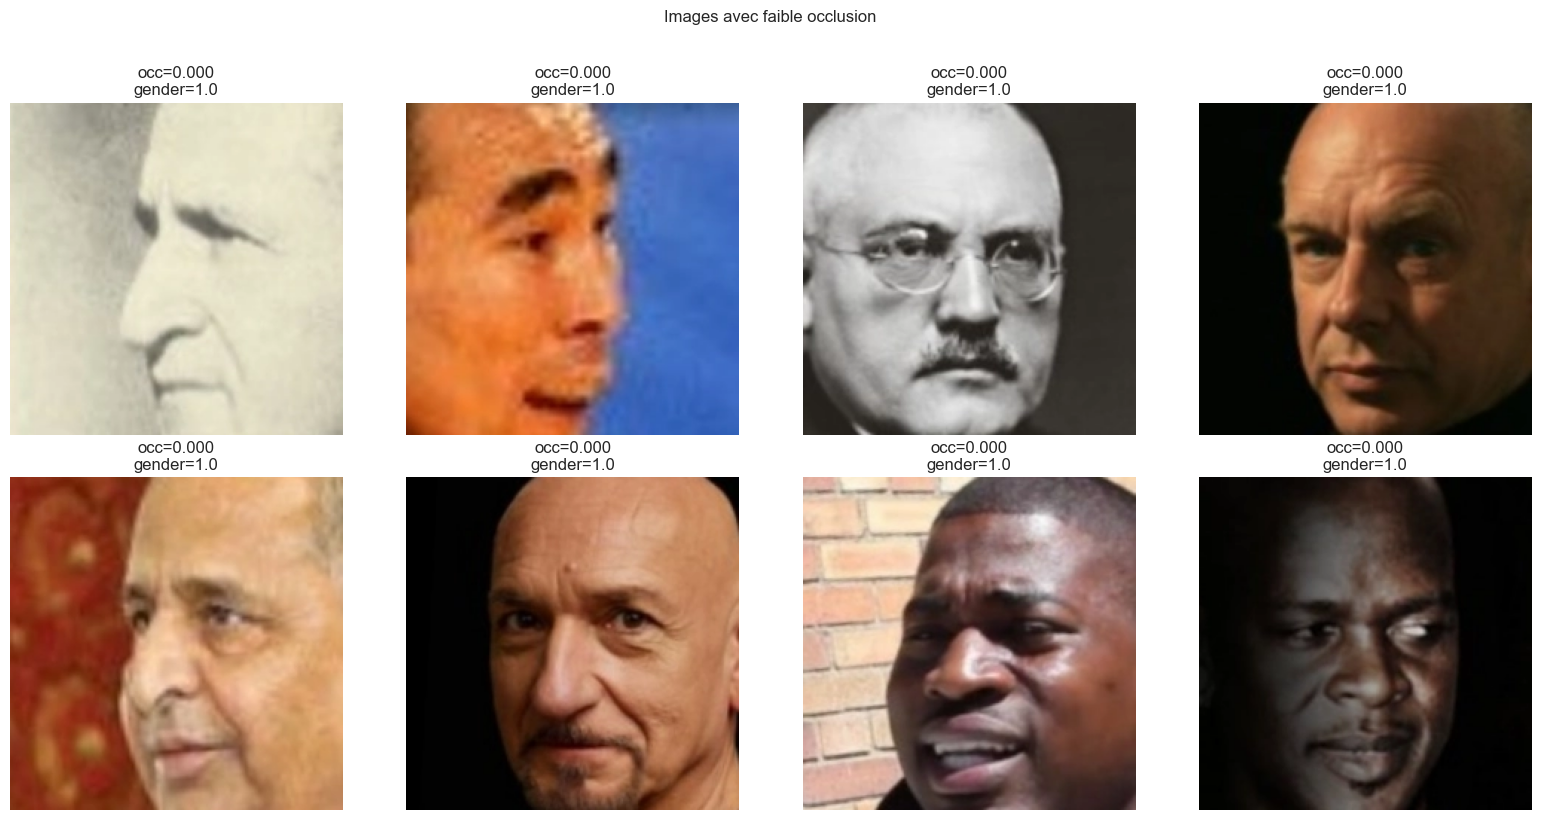

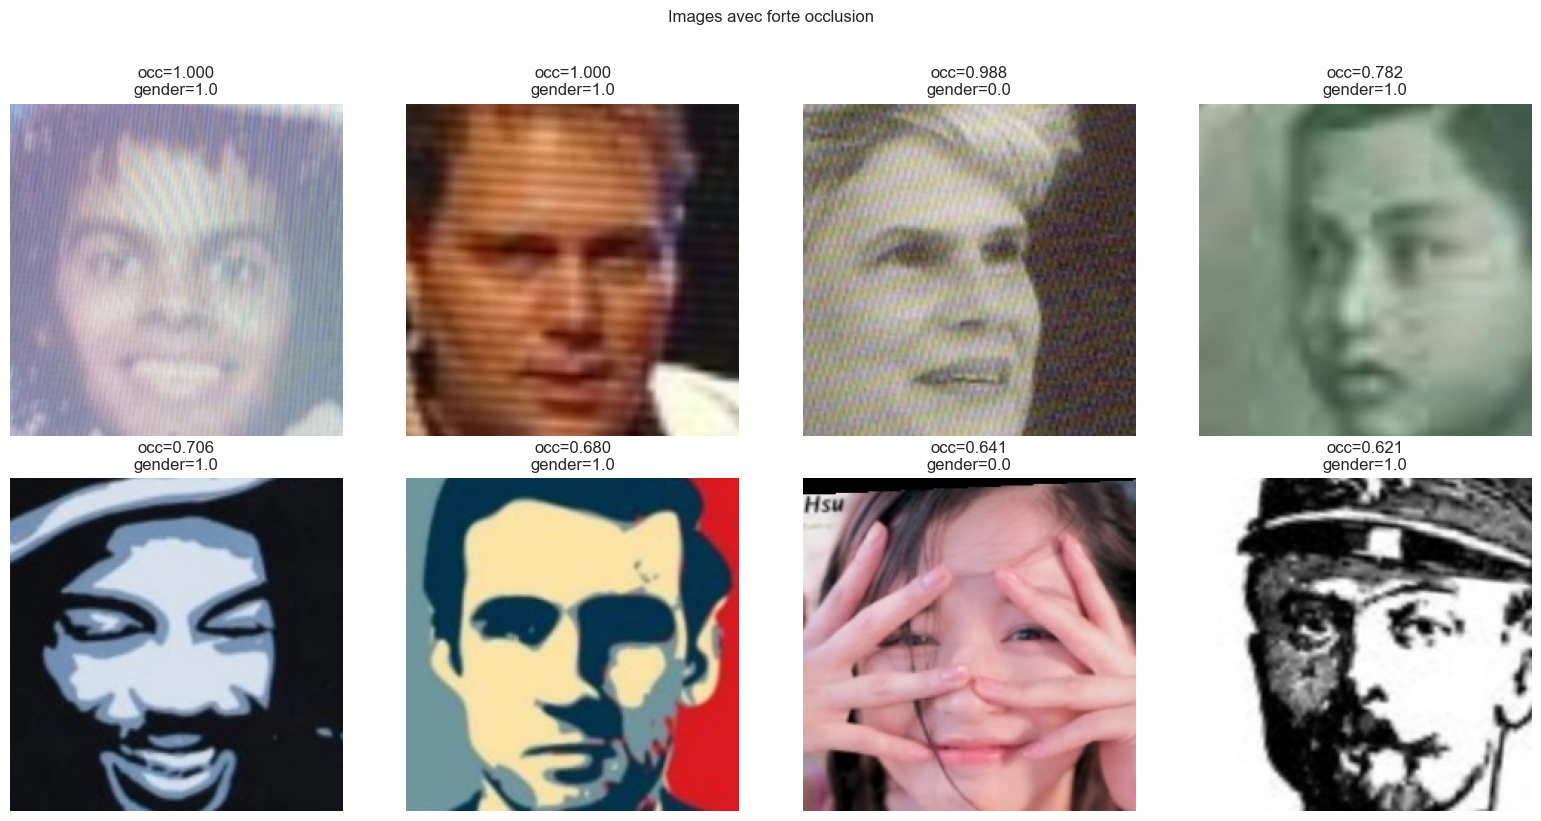

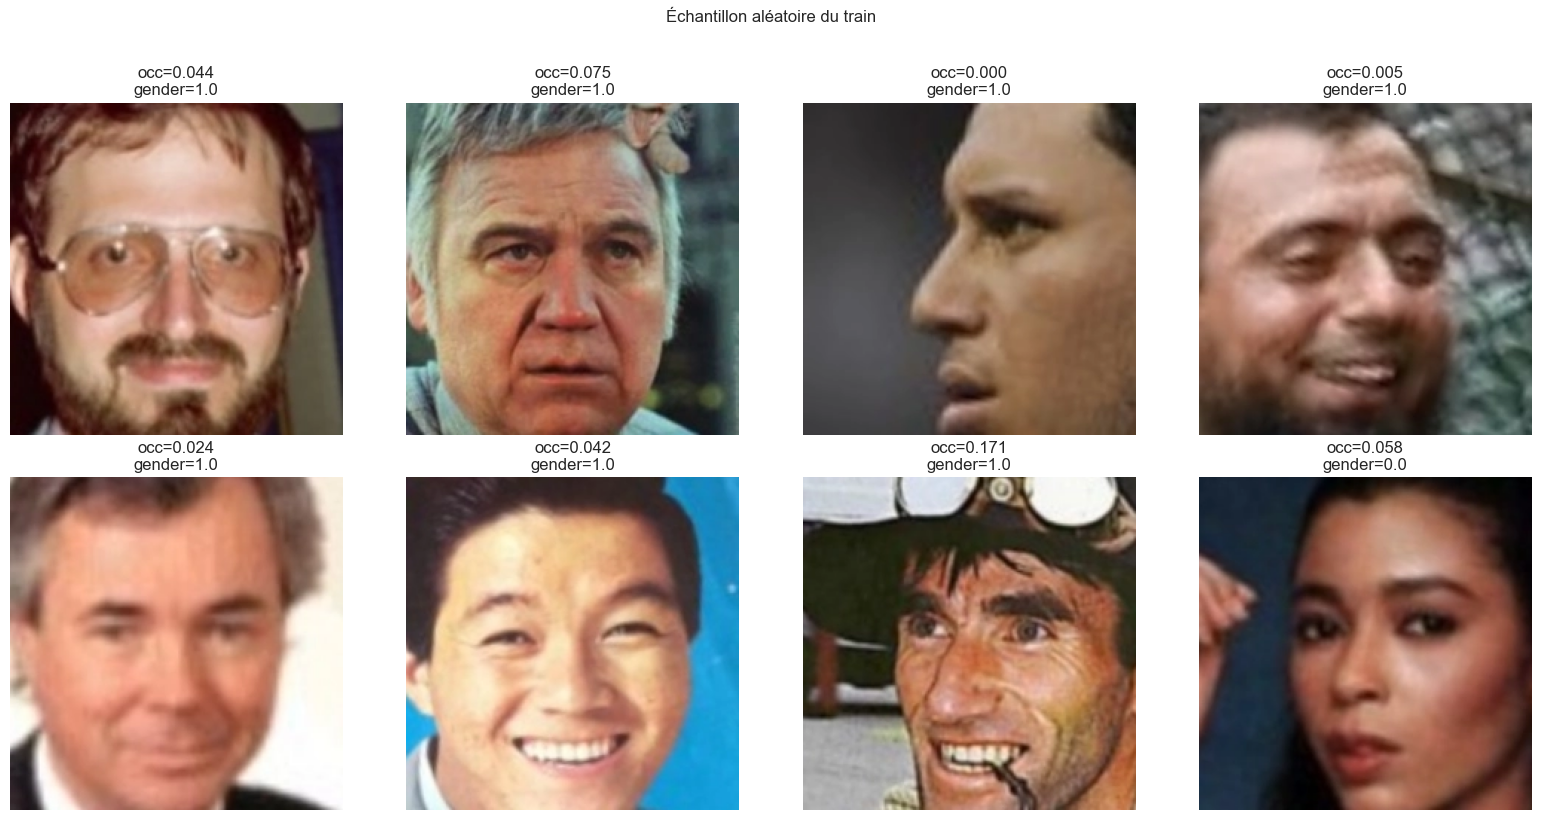

In [7]:
def show_image_grid(df, title, n=8, sort_by=None, ascending=True):
    subset = df.copy()
    if sort_by is not None and sort_by in subset.columns:
        subset = subset.sort_values(sort_by, ascending=ascending)
    subset = subset.head(n)
    cols = 4
    rows = int(np.ceil(len(subset) / cols)) if len(subset) else 1
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis('off')
    for ax, (_, row) in zip(axes, subset.iterrows()):
        img_path = CROPS_DIR / row['filename']
        try:
            with Image.open(img_path) as img:
                ax.imshow(img.convert('RGB'))
                ax.set_title(f"occ={row.get('FaceOcclusion', 'NA'):.3f}\ngender={row.get('gender', 'NA')}")
        except Exception:
            ax.text(0.5, 0.5, 'Impossible\nde charger\nl\'image', ha='center', va='center')
        ax.axis('off')
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

if 'FaceOcclusion' in train_df.columns:
    show_image_grid(train_df, 'Images avec faible occlusion', n=8, sort_by='FaceOcclusion', ascending=True)
    show_image_grid(train_df, 'Images avec forte occlusion', n=8, sort_by='FaceOcclusion', ascending=False)

if 'gender' in train_df.columns:
    show_image_grid(train_df.sample(min(8, len(train_df)), random_state=1), 'Échantillon aléatoire du train', n=8)

## 6. Relations entre variables

Cette section met en évidence les liens entre les cibles et la provenance des échantillons.

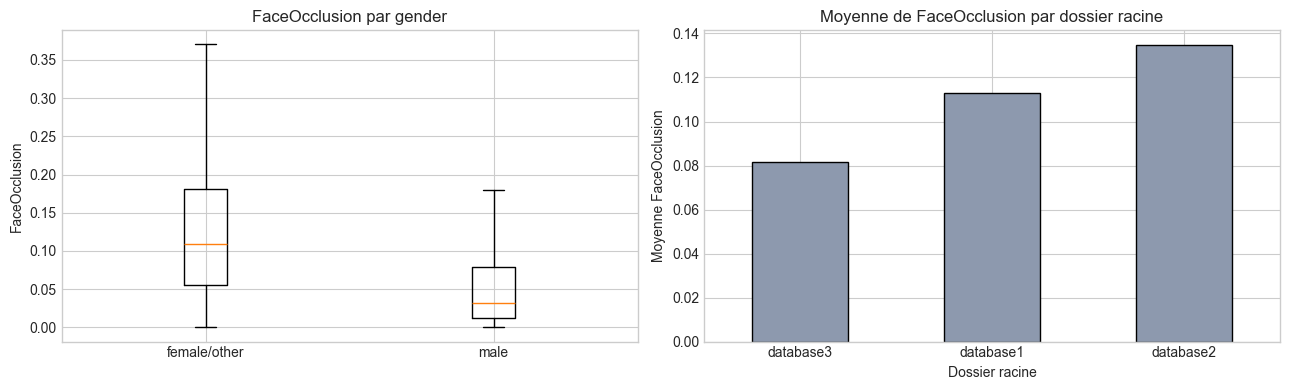

FaceOcclusion  (-0.001, 0.2]  (0.2, 0.4]  (0.4, 0.6]  (0.6, 0.8]  (0.8, 1.0]
gender                                                                      
0.0                     0.79       0.205       0.006         0.0         0.0
1.0                     0.93       0.068       0.001         0.0         0.0


In [9]:
plot_df = train_df.copy()
if 'FaceOcclusion' in plot_df.columns and 'gender' in plot_df.columns:
    plot_df['gender'] = plot_df['gender'].map({0.0: 'female/other', 1.0: 'male'}).fillna(plot_df['gender'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if {'FaceOcclusion', 'gender'}.issubset(plot_df.columns):
    groups = [grp['FaceOcclusion'].dropna().values for _, grp in plot_df.groupby('gender')]
    labels = [str(name) for name, _ in plot_df.groupby('gender')]
    axes[0].boxplot(groups, tick_labels=labels, showfliers=False)
    axes[0].set_title('FaceOcclusion par gender')
    axes[0].set_ylabel('FaceOcclusion')

if 'top_level_dir' in plot_df.columns and 'FaceOcclusion' in plot_df.columns:
    plot_df.groupby('top_level_dir')['FaceOcclusion'].mean().sort_values().plot(kind='bar', ax=axes[1], color='#8d99ae', edgecolor='black')
    axes[1].set_title('Moyenne de FaceOcclusion par dossier racine')
    axes[1].set_xlabel('Dossier racine')
    axes[1].set_ylabel('Moyenne FaceOcclusion')
    axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

if {'FaceOcclusion', 'gender'}.issubset(train_df.columns):
    print(pd.crosstab(train_df['gender'], pd.cut(train_df['FaceOcclusion'], bins=5), normalize='index').round(3))

## Conclusion rapide

Après exécution, ce notebook doit permettre de vérifier :
- l'intégrité des chemins vers les images,
- l'équilibre des labels,
- la variété des tailles et formats d'images,
- la cohérence visuelle entre les annotations et le contenu réel.

Les sorties des cellules donnent une base solide pour décider d'un prétraitement, d'un échantillonnage ou d'une stratégie d'entraînement.